$\textbf{Problem 1}$

C:\Users\AtoZ\AppData\Local\Temp\ipykernel_22368\537826684.py:11: RuntimeWarning: divide by zero encountered in log
  log_p = np.log(result) + k*np.log(theta) + (N-k)*np.log(1-theta)


θ̂ = 0.6534
lower bound = 0.5726
upper bound = 0.7218


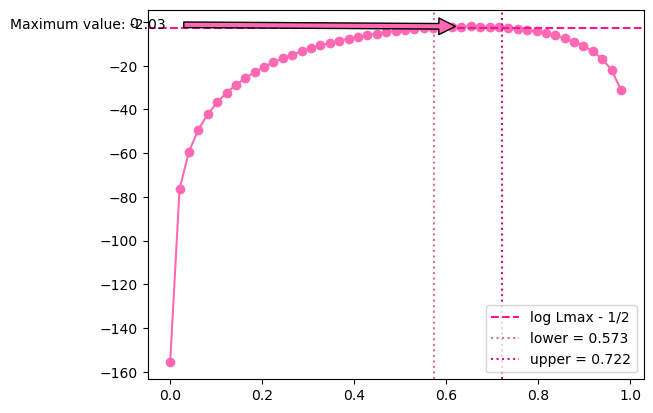

In [63]:
import math
import numpy as np
import matplotlib.pyplot as plt

N = 40
k = 26

result = math.comb(N, k)
theta = np.linspace(0.001,1,50)

log_p = np.log(result) + k*np.log(theta) + (N-k)*np.log(1-theta)  
plt.plot(theta,log_p,marker='o',color='hotpink')
max_index = np.argmax(log_p)
max_x = theta[max_index]
max_y = log_p[max_index]
plt.annotate(f'Maximum value: {max_y:.2f}', xy=(max_x, max_y), xytext=(max_x - 1, max_y - 1),
             arrowprops=dict(facecolor='hotpink', shrink=0.05))


#(c)
max_index = np.argmax(log_p)
max_theta = theta[max_index]
max_L = log_p[max_index]
Log_L = max_L-0.5
# (c)
Log_L = max_L - 0.5

# find lower bound (search left of peak)
lower_bound = None
for i in range(max_index, 0, -1):
    if log_p[i-1] <= Log_L <= log_p[i]:
        t0, t1 = theta[i-1], theta[i]
        l0, l1 = log_p[i-1], log_p[i]
        lower_bound = t0 + (Log_L - l0) * (t1 - t0) / (l1 - l0)
        break

# find upper bound (search right of peak)
upper_bound = None
for i in range(max_index, len(theta) - 1):
    if log_p[i] >= Log_L >= log_p[i+1]:
        t0, t1 = theta[i], theta[i+1]
        l0, l1 = log_p[i], log_p[i+1]
        upper_bound = t0 + (Log_L - l0) * (t1 - t0) / (l1 - l0)
        break

print(f"θ̂ = {max_theta:.4f}")
print(f"lower bound = {lower_bound:.4f}")
print(f"upper bound = {upper_bound:.4f}")

# plot
plt.axhline(Log_L, color='deeppink', linestyle='--', label='log Lmax - 1/2')
plt.axvline(lower_bound, color='palevioletred', linestyle=':', label=f'lower = {lower_bound:.3f}')
plt.axvline(upper_bound, color='mediumvioletred', linestyle=':', label=f'upper = {upper_bound:.3f}')
plt.legend()
plt.show()


(d) The width of the likelihood peak tells us which values of θ are consistent with the data. At the peak, θ̂ is the most probable value. Moving away from it in either direction, the likelihood drops, meaning those values are less supported by the observations. The 1σ interval is simply the range where the likelihood is still close enough to the maximum that we cannot rule those values out.

#### Problem 2: Why Noise Weighting Matters

You measure a signal that should follow a linear relation 

$$
y = ax + b
$$

but each data point has a different uncertainty $\sigma_i$.

You are given arrays ($x_i$, $y_i$, $\sigma_i$).

##### (a) Unweighted fit

Fit the model using ordinary least squares (ignore $\sigma_i). Plot the data and best-fit line. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [4]:
# Load data
data = pd.read_csv("/Users/AtoZ/downloads/weighted_regression_dataset.csv")

# Extract columns as arrays
x = data["x"].values
y = data["y"].values
sigma = data["sigma"].values

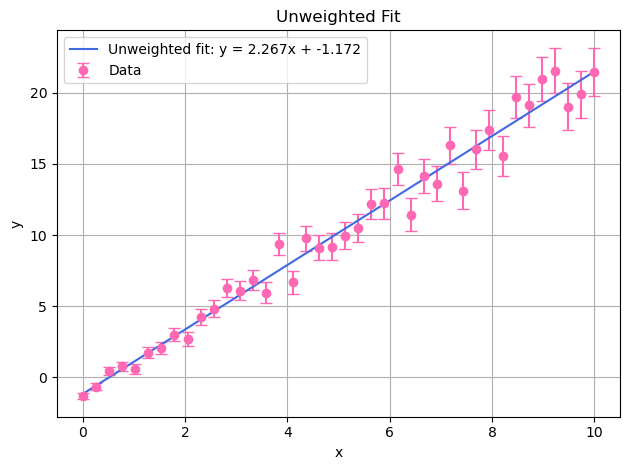

In [5]:
# polynomial of degree 1 with coefficients a and b
a, b = np.polyfit(x, y, 1)

x_fit = np.linspace(x.min(), x.max(), 300)
y_fit = a*x_fit + b

plt.figure()
plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=4, label='Data', color = "hotpink")
plt.plot(x_fit, y_fit, label=f'Unweighted fit: y = {a:.3f}x + {b:.3f}', color = "royalblue")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Unweighted Fit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

##### (b) Weighted fit

Now minimize 

$$
\chi^2 = \sum_i \frac{(y_i - a x_i - b)^2}{\sigma_i^2}.
$$

Plot the new best-fit line.

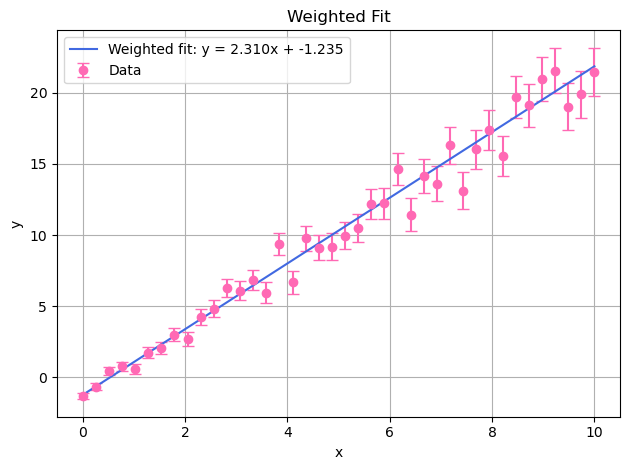

In [6]:
weights = 1 / sigma**2

a_w, b_w = np.polyfit(x, y, 1, w=weights)

y_fit_w = a_w * x_fit + b_w

# Plot
plt.figure()
plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=4, label='Data', color = "hotpink")
plt.plot(x_fit, y_fit_w, label=f'Weighted fit: y = {a_w:.3f}x + {b_w:.3f}', color = "royalblue")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Weighted Fit')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

##### (c) Comparison


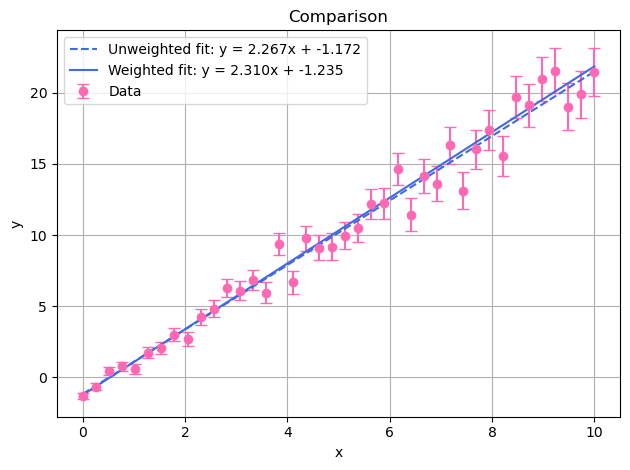

In [7]:
plt.figure()
plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=4, label='Data', color = "hotpink")
plt.plot(x_fit, y_fit, label=f'Unweighted fit: y = {a:.3f}x + {b:.3f}', color = "royalblue", linestyle='--')
plt.plot(x_fit, y_fit_w, label=f'Weighted fit: y = {a_w:.3f}x + {b_w:.3f}', color = "royalblue")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Comparison')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

1. Which points influenced the weighted fits more strongly?

The weighted fit is more strongly influenced by points with smaller incertainties/error bars because the weights are $w = 1/\sigma^2$. 

2. Why does inverse-variance weighting improve parameter estimation?

Inverse-variance weighting improves the precision of $a$ and $b$ by assigning higher weight to more precise measurements and lower weight to noisier measurements. This prevents high-uncertainty points from disproportionately influencing the fit. 



##### (d) Conceptual Connection

Suppose instead of fitting a line, you wanted to estimate the amplitude of a known waveform buried in noise with covariance matrix $\Sigma$.
Explain why you would expect the optimal estimator to weight the data by $\Sigma^{-1}$.

When estimating the amplitude of a known waveform buried in noise with covariance matrix $\Sigma$, the optimal estimator weights the data by $\Sigma^{-1}$ because it corresponds to maximizing the Gaussian likelihood and yields the minimum-variance unbiased estimator. The inverse covariance emphasizes directions with lower noise variance while downweighting noisier directions. Instead of weighting each data point by $1/\sigma_i^2$, the entire data vector is weighted by using the inverse covariance matrix, which reduces to inverse-variance weighting when the noise is uncorrelated and correctly handles correlations when it is not. 


#### Problem 3: Matched Filtering, Calibration, and Detection Efficiency

SyntaxError: f-string: unmatched '[' (<string>, line 11)

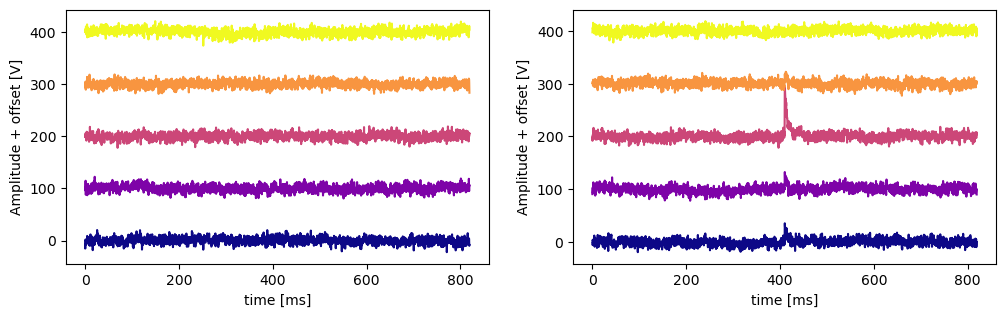

In [26]:
# Helper Functions: 
noise_data = np.load("noise_traces.npy")
from help import (
    foldpsd,
    calc_psd,
    optimal_filter_amp,
    fit_spectrum_curvefit
)

##### Part I: Matched Filter Amplitudes

1. Construct a noise power spectal density (PSD), J(f), estimate using the noise-only dataset. Plot the (one-sided) PSD on a log-log plot.

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import rfft, fft, ifft, fftfreq, rfftfreq
from scipy.optimize import curve_fit
from scipy.stats import norm
def calc_psd(x, fs=1.0, folded_over=True):
    """Return the PSD of an n-dimensional array, assuming that we want the PSD of the last axis.
    
    Parameters
    ----------
    x : array_like
        Array to calculate PSD of.
    fs : float, optional
        Sample rate of the data being taken, assumed to be in units of Hz.
    folded_over : bool, optional
        Boolean value specifying whether or not the PSD should be folded over. 
        If True, then the symmetric values of the PSD are multiplied by two, and
        we keep only the positive frequencies. If False, then the entire PSD is 
        saved, including positive and negative frequencies. Default is to fold
        over the PSD.
            
    Returns
    -------
    f : ndarray
        Array of sample frequencies
    psd : ndarray
        Power spectral density of 'x'
        
    """
    
    # calculate normalization for correct units
    norm = fs * x.shape[-1]
    
    if folded_over:
        # if folded_over = True, we calculate the Fourier Transform for only the positive frequencies
        if len(x.shape)==1:
            psd = (np.abs(rfft(x))**2.0)/norm
        else:
            psd = np.mean(np.abs(rfft(x))**2.0, axis=0)/norm
            
        # multiply the necessary frequencies by two (zeroth frequency should be the same, as
        # should the last frequency when x.shape[-1] is odd)
        psd[1:x.shape[-1]//2+1 - (x.shape[-1]+1)%2] *= 2.0
        f = rfftfreq(x.shape[-1], d=1.0/fs)
    else:
        # if folded_over = False, we calculate the Fourier Transform for all frequencies
        if len(x.shape)==1:
            psd = (np.abs(fft(x))**2.0)/norm
        else:
            psd = np.mean(np.abs(fft(x))**2.0, axis=0)/norm
            
        f = fftfreq(x.shape[-1], d=1.0/fs)
    return f, psd

def optimal_filter_amp(signal, template, psd, fs, coupling="AC"):
    """
    Compute the no-delay optimal filter amplitude for a single trace.

    Conventions / assumptions
    -------------------------
    - 'psd' is the full two-sided PSD (length = nbins).
    - FFT normalization follows the convention used in the OptimalFilter class:
        S = fft(template) / nbins / df
        V = fft(signal)   / nbins / df
      where df = fs / nbins.
    - If coupling == "AC" then the zero-frequency bin is ignored (psd[0] set to inf).
    - No time-shifts, no integralnorm, no chi2 / interpolation — just amplitude + sigma.

    Parameters
    ----------
    signal : 1D ndarray
        Time-domain trace (length nbins).
    template : 1D ndarray
        Template pulse (length nbins). Should be aligned/sampled to same grid.
    psd : 1D ndarray
        Two-sided PSD (length nbins). Can contain np.inf at index 0 for AC coupling.
    fs : float
        Sampling rate in Hz.
    coupling : {"AC","DC"}, optional
        If "AC" (default) will set psd[0] = np.inf to ignore DC.

    Returns
    -------
    amp : float
        Optimal filter amplitude (real scalar).
    sigma : float
        Expected 1-sigma amplitude resolution: 1/sqrt(norm).
    """
    signal = np.asarray(signal)
    template = np.asarray(template)
    psd = np.asarray(psd)

    if signal.ndim != 1 or template.ndim != 1 or psd.ndim != 1:
        raise ValueError("signal, template, and psd must be 1D arrays")

    nbins = signal.size
    if not (template.size == nbins == psd.size):
        raise ValueError("signal, template, and psd must have the same length")

    # frequency spacing
    df = fs / nbins

    # make a safe copy of PSD and apply coupling choice
    psd_safe = psd.astype(float).copy()
    if coupling == "AC":
        psd_safe[0] = np.inf

    # avoid division by zero on other bins (tiny floor)
    tiny = np.finfo(float).tiny
    psd_safe = np.where(np.isfinite(psd_safe), np.maximum(psd_safe, tiny), psd_safe)

    # FFT normalization matching the class conventions
    S = fft(template) / nbins / df   # complex
    V = fft(signal)   / nbins / df   # complex

    # frequency-domain filter (phi) and normalization (norm)
    phi = np.conjugate(S) / psd_safe
    norm = np.real(np.dot(phi, S)) * df   # scalar, should be >0 for nonzero template

    if norm <= 0:
        raise RuntimeError("Computed norm is non-positive (check template/psd)")

    # matched numerator
    num = np.sum(phi * V) * df         # complex in general
    amp = np.real(num) / norm          # final amplitude (real)

    # expected 1-sigma energy resolution
    sigma = 1.0 / np.sqrt(norm)

    return amp, sigma

def foldpsd(psd, fs):
    """
    Return the one-sided version of the inputted two-sided psd. Supports an n-dimensional array outputted by `calc_psd`.
    
    Parameters
    ----------
    psd : ndarray
        A two-sided psd to be converted to one-sided
    fs : float
        The sample rate used for the psd

    Returns
    -------
    f : ndarray
        The frequencies corresponding to the outputted one-sided psd
    psd_folded : ndarray
        The one-sided (folded over) psd corresponding to the inputted two-sided psd

    """

    psd_len = psd.shape[-1]
    psd_folded = np.copy(psd[...,:psd_len//2 + 1])
    psd_folded[..., 1:psd_len//2 + (psd_len)%2] *= 2.0
    f = rfftfreq(psd_len, d=1.0/fs)
    
    return f, psd_folded


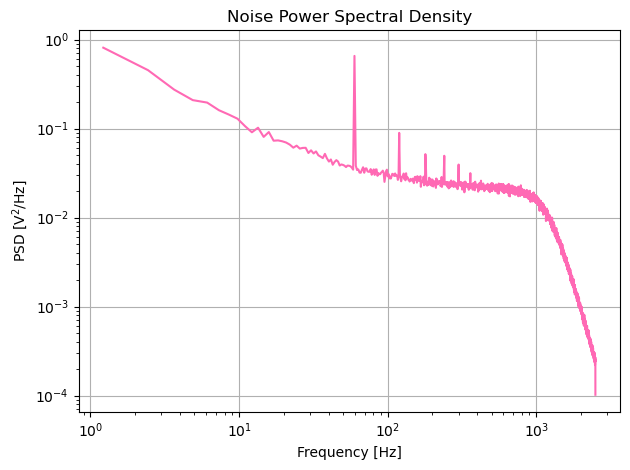

In [34]:
# sampling parameters
fs = 5e3
trace_length = 4096
dt = 1 / fs

# calculate PSD
# calc_psd: Return the PSD of an n-dimensional array, assuming that we want the PSD of the last axis.
f_full, psd_full = calc_psd(noise_data, fs=fs, folded_over=False)

# one-sided PSD for plotting
# foldpsd: Return the one-sided version of the inputted two-sided psd. Supports an n-dimensional array outputted by `calc_psd`.
f_1s, psd_1s = foldpsd(psd_full, fs)

plt.figure()
plt.loglog(f_1s[1:], psd_1s[1:], color = "hotpink")
plt.xlabel("Frequency [Hz]")
plt.ylabel("PSD [V$^2$/Hz]")
plt.title("Noise Power Spectral Density")
plt.tight_layout()
plt.grid(True)
plt.show()

2. Build a matched filter using a template pulse $s(t)$ and the measured PSD:

$$
a_{\mathrm{MF}} =
\frac{
\sum_k \tilde{s}^{\,*}(f_k)\,\tilde{d}(f_k)\,/\,J(f_k)
}{
\sum_k \left|\tilde{s}(f_k)\right|^2 \,/\, J(f_k)
}
$$

where $ \tilde{d}(f_k) \text{ and } \tilde{s}(f_k) $ are the Fourier transforms of the data and template, respectively. Our pulse template is normalized to have a maximum amplitude of one, and scales as 

$$
s(t) \propto e^{-t/\tau_{\mathrm{fall}}} - e^{-t/\tau_{\mathrm{rise}}}
$$

where $ \tau_{\mathrm{rise}} = 100~\mu\text{s}$ and $\tau_{\mathrm{fall}} = 5~\text{ms}.$

3. Apply the matched filter to all events and extract an amplitude for each pulse.

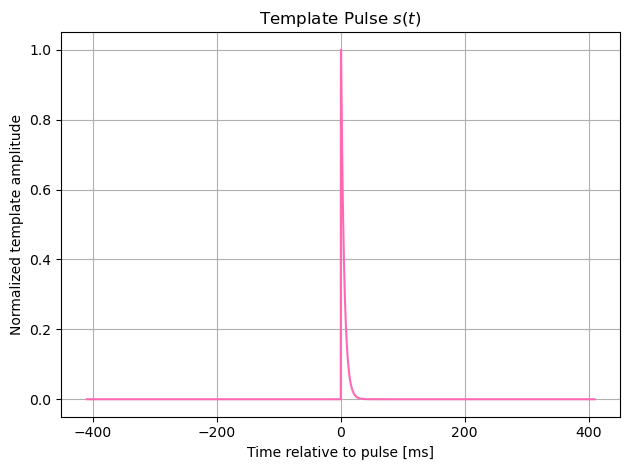

In [35]:
# the pulse peak is at index [trace_length // 2]
t = (np.arange(trace_length) - trace_length // 2) * dt

# everything before t = 0 must be zero
time_pulse = np.maximum(t, 0.0)

scale = np.exp(-time_pulse / 5e-3  ) - np.exp(-time_pulse / 100e-6)

# normalize to max amplitude of 1
scale /= np.max(scale)

plt.figure()
plt.plot(t * 1e3, scale, color = "hotpink")
plt.xlabel("Time relative to pulse [ms]")
plt.ylabel("Normalized template amplitude")
plt.title("Template Pulse $s(t)$")
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# one matched-filter amplitude per event
amps = np.empty(event_data.shape[0])

# uncertainty on each amplitude 
amps_sigma = np.empty(event_data.shape[0])

# Compute the no-delay optimal filter amplitude for a single trace.
for n, trace in enumerate(event_data):
    amp, sig = optimal_filter_amp(
        signal=trace,
        template=scale,
        psd=psd_full, 
        fs=fs,
        coupling="AC" 
    )
    # store values
    amps[n] = amp
    amps_sigma[n] = sig

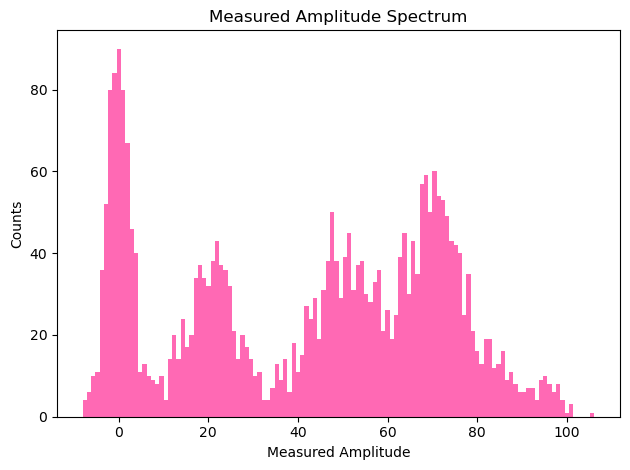

In [37]:
plt.figure()
plt.hist(amps, bins=120, color="hotpink")
plt.xlabel("Measured Amplitude")
plt.ylabel("Counts")
plt.title("Measured Amplitude Spectrum")
plt.tight_layout()
plt.show()

In [42]:
def _pick_top_hist_peaks(counts, centers, n):
    """Pick up to n well-separated peak centers from histogram counts."""
    sm = np.convolve(counts, np.ones(3)/3, mode='same')
    order = np.argsort(sm)[::-1]
    chosen = []
    min_sep = (centers[1] - centers[0]) * 6.0
    for idx in order:
        c = centers[idx]
        if all(abs(c - cc) > min_sep for cc in chosen):
            chosen.append(c)
        if len(chosen) >= n:
            break
    if len(chosen) < n:
        # fallback: even spacing
        qs = np.linspace(0.1, 0.9, n)
        chosen = list(np.quantile(centers, qs))
    return np.array(sorted(chosen))


def fit_spectrum_curvefit(amplitudes,
                          n_lines=3,
                          mus_guess=None,
                          sig_guess=None,
                          include_flat=True,
                          bins=120,
                          range_vals=None,
                          verbose=False):
    """
    Fit binned counts with n_lines Gaussians + optional flat background using scipy.curve_fit.

    Parameters
    ----------
    amplitudes : 1D array
        Amplitude measurements (one number per event).
    n_lines : int
        Number of Gaussian spectral lines to fit.
    mus_guess : sequence or None
        Optional initial guesses for Gaussian centers (length n_lines). If None, inferred from histogram peaks.
    sig_guess : sequence or None
        Optional initial guesses for standard deviations (length n_lines). If None, default small values based on data span.
    include_flat : bool
        If True, include a flat counts-per-bin background term.
    bins, range_vals : histogram binning passed to np.histogram
    verbose : bool
        Print fitted parameter summary.

    Returns
    -------
    result : dict with keys
        'bin_centers','bin_edges','counts','areas','mus','sigs','weights',
        'flat_counts_per_bin','flat_fraction_est','model_counts','popt','pcov'
    """
    x = np.asarray(amplitudes).ravel()
    N = x.size

    counts, edges = np.histogram(x, bins=bins, range=range_vals)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bw = edges[1] - edges[0]
    span = edges[-1] - edges[0]

    n_gauss = int(n_lines)
    # default guesses
    if mus_guess is None:
        mus_guess = _pick_top_hist_peaks(counts, centers, n_gauss)
    else:
        mus_guess = np.asarray(mus_guess).ravel()
        if mus_guess.size != n_gauss:
            raise ValueError("mus_guess must have length == n_lines")

    if sig_guess is None:
        # narrow for lines: few percent of span
        sig_guess = np.full(n_gauss, max(1e-3, 0.03 * span))
    else:
        sig_guess = np.asarray(sig_guess).ravel()
        if sig_guess.size != n_gauss:
            raise ValueError("sig_guess must have length == n_lines")

    # Model: counts per bin = sum_j area_j * pdf(center | mu_j, sigma_j) * bin_width + flatC
    def _model_counts(x_centers, *p):
        out = np.zeros_like(x_centers, dtype=float)
        ptr = 0
        for g in range(n_gauss):
            area = p[ptr]; mu = p[ptr+1]; sig = p[ptr+2]
            ptr += 3
            out += area * norm.pdf(x_centers, loc=mu, scale=max(1e-9, abs(sig))) * bw
        if include_flat:
            flatC = p[ptr]
            out = out + max(0.0, flatC)
        return out

    # initial parameter vector p0: [area1, mu1, sig1, area2, mu2, sig2, ..., flatC?]
    total_guess_area = N
    base_area = total_guess_area / (n_gauss + (1 if include_flat else 0))
    p0 = []
    for i in range(n_gauss):
        # approximate peak height -> area guess (robust)
        idx_closest = np.argmin(np.abs(centers - mus_guess[i]))
        peak_h = counts[idx_closest]
        est_area = peak_h * (sig_guess[i] * np.sqrt(2*np.pi))
        est_area = max(est_area, base_area * 0.1)
        p0.extend([float(est_area), float(mus_guess[i]), float(sig_guess[i])])

    if include_flat:
        flat_guess = max(0.0, np.median(counts) * 0.2)
        p0.append(float(flat_guess))

    p0 = np.asarray(p0, dtype=float)

    # bounds
    lower = []
    upper = []
    for g in range(n_gauss):
        lower.extend([0.0, edges[0] - 0.2*span, 1e-6])        # area >=0, mu within extended range, sig > 0
        upper.extend([N*10.0, edges[-1] + 0.2*span, span*1.0])
    if include_flat:
        lower.append(0.0)
        upper.append(float(N*0.5))

    try:
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, bounds=(lower, upper), maxfev=50000)
    except Exception as exc:
        if verbose:
            print("curve_fit exception (retrying without bounds):", exc)
        popt, pcov = curve_fit(_model_counts, centers, counts, p0=p0, maxfev=50000)

    # unpack
    ptr = 0
    areas = []
    mus = []
    sigs = []
    for g in range(n_gauss):
        a = float(popt[ptr]); mu = float(popt[ptr+1]); s = abs(float(popt[ptr+2]))
        ptr += 3
        areas.append(a); mus.append(mu); sigs.append(s)

    flatC = float(popt[ptr]) if include_flat else 0.0

    # approximate fractions (area-weighted)
    denom = np.sum(areas) + (flatC * span / bw if include_flat else 0.0)
    if denom <= 0:
        weights = np.array([a / max(1e-12, np.sum(areas)) for a in areas])
        flat_frac = 0.0
    else:
        weights = np.array(areas) / denom
        flat_frac = (flatC * span / bw) / denom if include_flat else 0.0

    model_counts = _model_counts(centers, *popt)

    result = {
        "bin_centers": centers,
        "bin_edges": edges,
        "counts": counts,
        "areas": np.array(areas),
        "mus": np.array(mus),
        "sigs": np.array(sigs),
        "weights": weights,
        "flat_counts_per_bin": float(flatC),
        "flat_fraction_est": float(flat_frac),
        "model_counts": model_counts,
        "popt": popt,
        "pcov": pcov
    }

    if verbose:
        print("mus:", result["mus"])
        print("sigs:", result["sigs"])
        print("areas:", result["areas"])
        print("flat per bin:", result["flat_counts_per_bin"])
        print("flat fraction (est):", result["flat_fraction_est"])

    return result


#### Part II: Spectral Model and Peak Extraction (Using Provided Fit Function)

1. Construct a histogram of the reconstructed amplitudes and call fit spectrum to obtain the
fit.
2. Plot the histogram (counts) and overlay the fitted $\lambda_j$ (expected counts per bin) from the fit,
as well as the individual Gaussian components and the flat background contribution.

In [43]:
range_vals = (-10, 110)

# Use fit_spectrum_curvefit to construct a histogram
hist = fit_spectrum_curvefit(
    amps,
    n_lines=4,
    mus_guess=None,
    sig_guess=None,
    include_flat=True,
    bins=120,
    range_vals=range_vals,
    verbose=True
)

# extract params
centers = hist["bin_centers"]
edges = hist["bin_edges"]
counts = hist["counts"]
bw = edges[1] - edges[0]
model_counts = hist["model_counts"]
areas = hist["areas"]
mus = hist["mus"]
sigs = hist["sigs"]
flatC = hist["flat_counts_per_bin"]


mus: [-5.88808972e-02  2.08979783e+01  4.97718536e+01  7.05575320e+01]
sigs: [2.49299381 5.09573986 6.33187546 6.49740424]
areas: [574.33261358 457.16943684 587.99190889 842.59064176]
flat per bin: 4.482771119609617
flat fraction (est): 0.1793098206014457


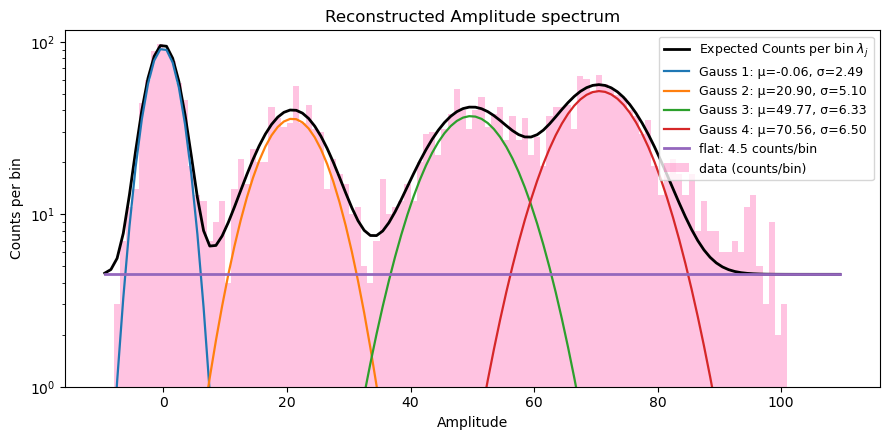

In [44]:
from scipy.stats import norm

plt.figure(figsize=(9, 4.5))
plt.bar(centers, counts, width=bw, alpha=0.4, color = "hotpink", label="data (counts/bin)")
plt.plot(centers, model_counts, "k-", lw=2, label="Expected Counts per bin $\lambda_j$")

# individual Gaussian components
for i in range(len(areas)):
    one_gauss = areas[i] * norm.pdf(centers, loc=mus[i], scale=sigs[i]) * bw
    plt.plot(
        centers, one_gauss, lw=1.6,
        label=f"Gauss {i+1}: μ={mus[i]:.2f}, σ={sigs[i]:.2f}"
    )

# flat background component
plt.plot(centers, np.full_like(centers, flatC), lw=2, label=f"flat: {flatC:.1f} counts/bin")

plt.xlabel("Amplitude")
plt.ylabel("Counts per bin")
plt.title("Reconstructed Amplitude spectrum")
plt.yscale("log")  # typical for spectra
plt.ylim(1, max(10, counts.max()*1.2))
plt.legend(ncol=1, fontsize=9)
plt.tight_layout()
plt.show()

3. Identify the three signal peaks and record their fitted amplitudes $A_1$, $A_2$, $A_3$, as well as for the ‘noise blob’. Use $\sigma_i$ from the fitter as the resolution for each peak.

In [47]:
# ignoring noise blob
ignore_blob = mus > 10.0 

lines_index = np.where(ignore_blob)[0]

# sort signal peaks low to high amplitude
lines_index = lines_index[np.argsort(mus[lines_index])]

# remaining Gaussian is noise blob
blob_index = np.setdiff1d(np.arange(len(mus)), lines_index)[0]

# extract values
A1, A2, A3 = mus[lines_index]
sig1, sig2, sig3 = sigs[lines_index]

print(f"Signal peaks:")
print(f"  A1 = {A1:.2f}, σ1 = {sig1:.2f}")
print(f"  A2 = {A2:.2f}, σ2 = {sig2:.2f}")
print(f"  A3 = {A3:.2f}, σ3 = {sig3:.2f}")
print(f"Noise blob: μ={mus[blob_index]:.2f}, σ={sigs[blob_index]:.2f}")

Signal peaks:
  A1 = 20.90, σ1 = 5.10
  A2 = 49.77, σ2 = 6.33
  A3 = 70.56, σ3 = 6.50
Noise blob: μ=-0.06, σ=2.49


4. Include one diagnostic plot of the negative log-likelihood evaluated versus $µ_1$ (scan a small window around the fitted value) to demonstrate the likelihood peak and uncertainty behavior.

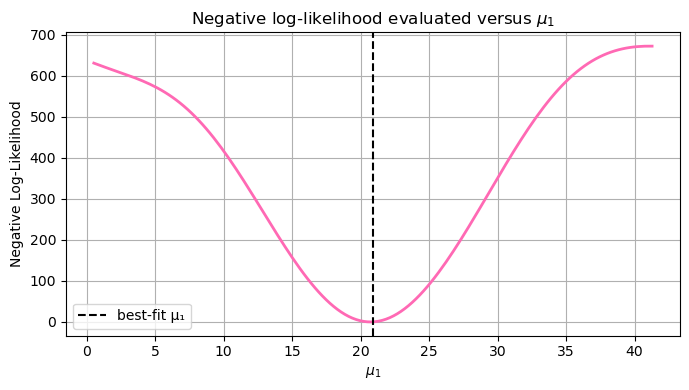

In [48]:
from scipy.stats import norm

bin_w = edges[1] - edges[0]

mu0 = lines_index[0] 
mu1_best = mus[mu0]

mu_vals = np.linspace(mu1_best - 4.0 * sigs[mu0], mu1_best + 4.0 * sigs[mu0], 150)

def poisson_nll_for_mu(mu_test):
    
    test_means = mus.copy()
    test_means[mu0] = mu_test

    expected = np.zeros_like(centers, dtype=float)

    for i in range(len(areas)):
        expected += areas[i] * norm.pdf(centers, test_means[i], abs(sigs[i])) * bin_w

    expected += flatC
    expected = np.clip(expected, 1e-12, None)

    return np.sum(expected - counts * np.log(expected))

# evaluate likelihood curve
nll_curve = np.array([poisson_nll_for_mu(mu) for mu in mu_vals])

# plot diagnostic
plt.figure(figsize=(7,4))
plt.plot(mu_vals, nll_curve - nll_curve.min(), lw=2, color="hotpink")
plt.axvline(mu1_best, linestyle="--", color="k", label="best-fit μ₁")
plt.xlabel(r"$\mu_1$")
plt.ylabel(r"Negative Log-Likelihood")
plt.title("Negative log-likelihood evaluated versus $\mu_1$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##### Part III: Energy Calibration

You will be provided with the true energies of the three lines:

$$
E_1^{\mathrm{true}} = 25~\mathrm{keV}, \qquad
E_2^{\mathrm{true}} = 65~\mathrm{keV}, \qquad
E_3^{\mathrm{true}} = 100~\mathrm{keV}.
$$

The detector response follows the nonlinear saturation model

$$
E_{\mathrm{recon}} = a\left(1 - \exp\left(-\frac{E_{\mathrm{true}}}{b}\right)\right).
$$

##### 1. Fit for calibration parameters $a$ and $b$.


In [49]:
from scipy.optimize import curve_fit

E_true = np.array([25.0, 65.0, 100.0])
A_meas = np.array([A1, A2, A3])

def calibration(E, a, b):
    return a * (1.0 - np.exp(-E / b))

a0 = 1.5 * np.max(A_meas)
b0 = np.mean(E_true)
popt, pcov = curve_fit(calibration, E_true, A_meas, p0=[a0, b0])
a_cal, b_cal = popt

print("a_cal =", a_cal)
print("b_cal =", b_cal)

a_cal = 183.02243885103184
b_cal = 205.22611890191502


##### 2. Construct the inverse calibration function to convert measured amplitudes to reconstructed energy $E_{\mathrm{rec}}$.


In [50]:
def energy_from_amplitude(A, a_cal, b_cal):
    A = np.asarray(A, dtype=float)
    inside = 1.0 - A / a_cal
    inside = np.clip(inside, 1e-12, None)
    return -b_cal * np.log(inside)

##### 3. Convert the full amplitude spectrum into an energy spectrum.

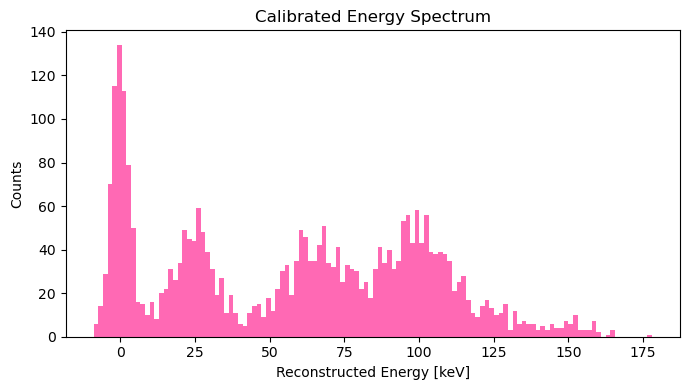

In [51]:
E_rec = energy_from_amplitude(amps, a_cal, b_cal)

plt.figure(figsize=(7,4))
plt.hist(E_rec, bins=120, color="hotpink")
plt.xlabel("Reconstructed Energy [keV]")
plt.ylabel("Counts")
plt.title("Calibrated Energy Spectrum")
plt.tight_layout()
plt.show()

##### 4. Comment on the benefits of the above saturation model versus a polynomial/spline fit.

The saturation model has two important qualities: 

1. It Increases monotonically (as energy increases, amplitude inreases). This is helpful because we know that the amplitude is strictly increasing for all E values. If this were not the case, the same amplitude could correspond to two different energies which would introduce more ambiguity. 

2. The detector response approaches a maximum amplitude. This keeps the calibration reasonable even beyond the measured range and prevents unbounded growth. 

These qualities are especially helpful when only a small number of calibration points are available, which is the case here. With only 3 calibration points (25, 65, and 100 keV), the polynomical/spline fit could overfit the data and behave unpredictably outside the calibration range. The saturation model is useful for data not available outside a certain range.


$\textbf{Part 4}$

Noise blob:  µ_n = -0.059 V,  σ_n = 2.493 V
Amplitude threshold (µ_n + 5σ_n): 12.406 V
Energy threshold: 14.41 keV


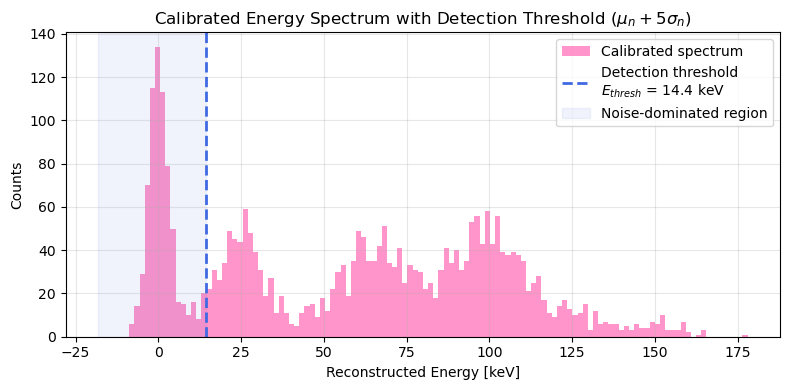


Events above threshold: 2307 / 3000  (76.9%)


In [52]:
mu_noise  = mus[blob_index]       # µ_n in amplitude units
sig_noise = sigs[blob_index]      # σ_n in amplitude units


A_thresh = mu_noise + 5 * sig_noise
print(f"Noise blob:  µ_n = {mu_noise:.3f} V,  σ_n = {sig_noise:.3f} V")
print(f"Amplitude threshold (µ_n + 5σ_n): {A_thresh:.3f} V")
E_thresh = energy_from_amplitude(A_thresh, a_cal, b_cal)
print(f"Energy threshold: {E_thresh:.2f} keV")


fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(E_rec, bins=120, color="hotpink", alpha=0.7, label="Calibrated spectrum")
ax.axvline(E_thresh, color="royalblue", linewidth=2, linestyle="--",
           label=f"Detection threshold\n$E_{{thresh}}$ = {E_thresh:.1f} keV")
ax.axvspan(ax.get_xlim()[0], E_thresh, alpha=0.08, color="royalblue",
           label="Noise-dominated region")

ax.set_xlabel("Reconstructed Energy [keV]")
ax.set_ylabel("Counts")
ax.set_title(r"Calibrated Energy Spectrum with Detection Threshold ($\mu_n + 5\sigma_n$)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


n_above = np.sum(E_rec > E_thresh)
n_total = len(E_rec)
print(f"\nEvents above threshold: {n_above} / {n_total}  ({100*n_above/n_total:.1f}%)")

$\textbf{Part 5}$

Efficiency curve fit:
  50% efficiency point:  E_50 = 14.42 keV
  Transition width:      σ    = 2.89 keV


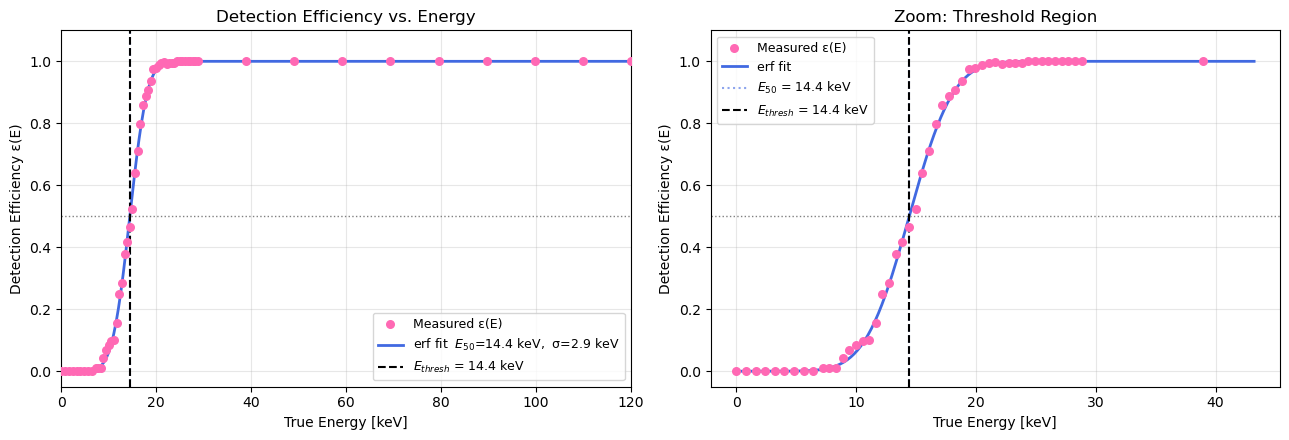


  E_true [keV]       ε
------------------------
          0.00   0.000
          0.80   0.000
          1.60   0.000
          2.40   0.000
          3.20   0.000
          4.00   0.000
          4.80   0.000
          5.60   0.000
          6.40   0.000
          7.20   0.012
          7.76   0.010
          8.31   0.012
          8.86   0.042
          9.42   0.068
          9.97   0.084
         10.53   0.096
         11.08   0.100
         11.63   0.156
         12.19   0.248
         12.74   0.284
         13.30   0.378
         13.85   0.418
         14.41   0.466
         14.96   0.522
         15.51   0.640
         16.07   0.710
         16.62   0.798
         17.18   0.858
         17.73   0.888
         18.28   0.906
         18.84   0.938
         19.39   0.976
         19.95   0.980
         20.50   0.988
         21.05   0.994
         21.61   0.998
         22.16   0.992
         22.72   0.994
         23.27   0.996
         23.82   0.994
         24.38   1.000
        

In [53]:
E_true_test = np.concatenate([
    np.linspace(0, E_thresh * 0.5, 10),        # well below threshold
    np.linspace(E_thresh * 0.5, E_thresh * 2, 40),  # near threshold (dense)
    np.linspace(E_thresh * 2, 120, 10)         # well above threshold
])
E_true_test = np.unique(np.sort(E_true_test))

N_inject = 500   
efficiencies = []

for E_true in E_true_test:
    A_true = calibration(E_true, a_cal, b_cal)
    fake_pulse = scale * A_true   # shape: (trace_length,)
    noise_idx = np.random.choice(len(noise_data), size=N_inject, replace=True)
    injected = noise_data[noise_idx] + fake_pulse
    amps_inj = np.empty(N_inject)
    for i, trace in enumerate(injected):
        amp, _ = optimal_filter_amp(
            signal=trace,
            template=scale,
            psd=psd_full,
            fs=fs,
            coupling="AC"
        )
        amps_inj[i] = amp

    E_rec_inj = energy_from_amplitude(amps_inj, a_cal, b_cal)
    eff = np.sum(E_rec_inj > E_thresh) / N_inject
    efficiencies.append(eff)

efficiencies = np.array(efficiencies)

from scipy.special import erf
from scipy.optimize import curve_fit

def efficiency_model(E, E50, width):
    """
    Sigmoid efficiency curve based on Gaussian noise:
      ε(E) = 0.5 * [1 + erf((E - E50) / (sqrt(2) * width))]
    E50  : energy at 50% efficiency
    width: Gaussian smearing width (related to energy resolution)
    """
    return 0.5 * (1 + erf((E - E50) / (np.sqrt(2) * width)))
p0 = [E_thresh, E_thresh * 0.1]
try:
    popt_eff, pcov_eff = curve_fit(
        efficiency_model, E_true_test, efficiencies,
        p0=p0, bounds=([0, 0], [200, 50]), maxfev=10000
    )
    E50_fit, width_fit = popt_eff
    fit_success = True
    print(f"Efficiency curve fit:")
    print(f"  50% efficiency point:  E_50 = {E50_fit:.2f} keV")
    print(f"  Transition width:      σ    = {width_fit:.2f} keV")
except Exception as e:
    print(f"Fit did not converge: {e}")
    fit_success = False

E_plot = np.linspace(0, 120, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.scatter(E_true_test, efficiencies, color="hotpink", zorder=5,
           label="Measured ε(E)", s=30)

if fit_success:
    ax.plot(E_plot, efficiency_model(E_plot, *popt_eff),
            color="royalblue", lw=2,
            label=f"erf fit  $E_{{50}}$={E50_fit:.1f} keV,  σ={width_fit:.1f} keV")
    ax.axvline(E50_fit, color="royalblue", linestyle=":", alpha=0.6)

ax.axvline(E_thresh, color="black", linestyle="--", lw=1.5,
           label=f"$E_{{thresh}}$ = {E_thresh:.1f} keV")
ax.axhline(0.5, color="gray", linestyle=":", lw=1)

ax.set_xlabel("True Energy [keV]")
ax.set_ylabel("Detection Efficiency ε(E)")
ax.set_title("Detection Efficiency vs. Energy")
ax.set_xlim(0, 120)
ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax2 = axes[1]
mask = E_true_test < E_thresh * 3
ax2.scatter(E_true_test[mask], efficiencies[mask],
            color="hotpink", zorder=5, s=30, label="Measured ε(E)")

if fit_success:
    E_zoom = np.linspace(0, E_thresh * 3, 300)
    ax2.plot(E_zoom, efficiency_model(E_zoom, *popt_eff),
             color="royalblue", lw=2, label="erf fit")
    ax2.axvline(E50_fit, color="royalblue", linestyle=":", alpha=0.6,
                label=f"$E_{{50}}$ = {E50_fit:.1f} keV")

ax2.axvline(E_thresh, color="black", linestyle="--", lw=1.5,
            label=f"$E_{{thresh}}$ = {E_thresh:.1f} keV")
ax2.axhline(0.5, color="gray", linestyle=":", lw=1)

ax2.set_xlabel("True Energy [keV]")
ax2.set_ylabel("Detection Efficiency ε(E)")
ax2.set_title("Zoom: Threshold Region")
ax2.set_ylim(-0.05, 1.1)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"\n{'E_true [keV]':>14}  {'ε':>6}")
print("-" * 24)
for E, eff in zip(E_true_test, efficiencies):
    print(f"{E:14.2f}  {eff:6.3f}")

$\textbf{Part 6}$

Running Matched Filter analysis...
  MF  threshold : 14.41 keV
  MF  σ_E (25/65/100 keV) : [ 6.45046966  9.75204892 11.85647232]

Running Peak estimator analysis...
  Peak threshold : 26.11 keV
  Peak σ_E (25/65/100 keV) : [ 4.07826775 33.88749132 13.74072223]

Running Integral estimator analysis...
  Integral threshold : 1.05 keV
  Integral σ_E (25/65/100 keV) : [4.6572207  8.72796517 9.75701103]

Computing efficiency curves (takes ~1 min)...


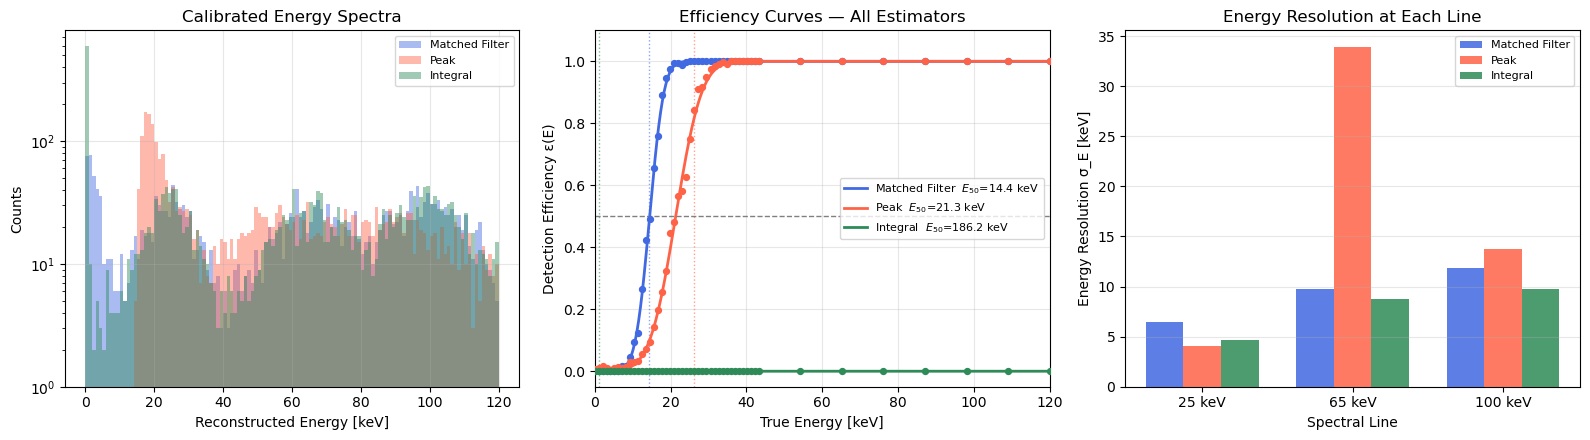


                         FINAL COMPARISON TABLE                         
Estimator           σ_E@25keV  σ_E@65keV  σ_E@100keV   E_thresh     E_50
------------------------------------------------------------------------
Matched Filter           6.45       9.75       11.86      14.41    14.45
Peak                     4.08      33.89       13.74      26.11    21.32
Integral                 4.66       8.73        9.76       1.05   186.22
  All values in keV


In [58]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import erf
from scipy.stats import norm

def calibrate_estimator(A_meas, E_true=np.array([25., 65., 100.])):
    def cal_model(E, a, b):
        return a * (1.0 - np.exp(-E / b))
    a0 = 1.5 * np.max(A_meas)
    b0 = np.mean(E_true)
    popt, _ = curve_fit(cal_model, E_true, A_meas, p0=[a0, b0])
    return popt  # (a_cal, b_cal)

def energy_from_amp(A, a_cal, b_cal):
    A = np.asarray(A, dtype=float)
    inside = np.clip(1.0 - A / a_cal, 1e-12, None)
    return -b_cal * np.log(inside)

def resolution_at_lines(hist_result):
    mus  = np.array(hist_result["mus"])
    sigs = np.array(hist_result["sigs"])

    # Sort by centre
    order       = np.argsort(mus)
    mus_sorted  = mus[order]
    sigs_sorted = sigs[order]

    # Noise blob = lowest mu → drop it, take next 3
    signal_mus  = mus_sorted[1:4]
    signal_sigs = sigs_sorted[1:4]
    return signal_mus, signal_sigs

def sigma_energy(sigma_A, A, a_cal, b_cal):
    dEdA = b_cal / (a_cal - A)
    return np.abs(dEdA) * sigma_A

def get_noise_threshold(hist_result, a_cal, b_cal, n_sigma=5):
    mus  = np.array(hist_result["mus"])
    sigs = np.array(hist_result["sigs"])
    blob_idx   = np.argmin(mus)
    A_thresh   = mus[blob_idx] + n_sigma * sigs[blob_idx]
    E_thresh   = energy_from_amp(A_thresh, a_cal, b_cal)
    return A_thresh, E_thresh

def measure_efficiency(estimator_fn, noise_data, scale, a_cal, b_cal,
                        E_thresh, E_true_test, N_inject=300):
    # Forward calibration reused from Part III
    def forward_cal(E, a, b):
        return a * (1.0 - np.exp(-E / b))

    efficiencies = []
    for E_true in E_true_test:
        A_true     = forward_cal(E_true, a_cal, b_cal)
        fake_pulse = scale * A_true
        idx        = np.random.choice(len(noise_data), size=N_inject, replace=True)
        injected   = noise_data[idx] + fake_pulse          # (N_inject, 4096)

        amps_inj  = np.array([estimator_fn(tr) for tr in injected])
        E_rec_inj = energy_from_amp(amps_inj, a_cal, b_cal)
        efficiencies.append(np.sum(E_rec_inj > E_thresh) / N_inject)

    return np.array(efficiencies)

def fit_erf(E_test, efficiencies):
    """Fit erf sigmoid; return (E50, width) or (nan, nan) on failure."""
    def eff_model(E, E50, w):
        return 0.5 * (1.0 + erf((E - E50) / (np.sqrt(2.0) * w)))
    try:
        popt, _ = curve_fit(eff_model, E_test, efficiencies,
                            p0=[np.median(E_test), 5.0],
                            bounds=([0, 0.1], [200, 50]),
                            maxfev=20000)
        return popt
    except Exception:
        return np.array([np.nan, np.nan])

print("Running Matched Filter analysis...")

hist_mf              = fit_spectrum_curvefit(amps, n_lines=4, bins=120,
                                             range_vals=(-10, 110),
                                             include_flat=True, verbose=False)
mus_mf, sigs_mf      = resolution_at_lines(hist_mf)
a_mf, b_mf           = calibrate_estimator(mus_mf)
sigE_MF              = sigma_energy(sigs_mf, mus_mf, a_mf, b_mf)
_, E_thresh_mf       = get_noise_threshold(hist_mf, a_mf, b_mf)
E_rec_mf             = energy_from_amp(amps, a_mf, b_mf)

print(f"  MF  threshold : {E_thresh_mf:.2f} keV")
print(f"  MF  σ_E (25/65/100 keV) : {sigE_MF}")

print("\nRunning Peak estimator analysis...")

amps_peak            = np.array([np.max(tr) for tr in event_data])
hist_peak            = fit_spectrum_curvefit(amps_peak, n_lines=4, bins=120,
                                             range_vals=(np.percentile(amps_peak, 0.1),
                                                         np.percentile(amps_peak, 99.9)),
                                             include_flat=True, verbose=False)
mus_peak, sigs_peak  = resolution_at_lines(hist_peak)
a_peak, b_peak       = calibrate_estimator(mus_peak)
sigE_peak            = sigma_energy(sigs_peak, mus_peak, a_peak, b_peak)
_, E_thresh_peak     = get_noise_threshold(hist_peak, a_peak, b_peak)
E_rec_peak           = energy_from_amp(amps_peak, a_peak, b_peak)

print(f"  Peak threshold : {E_thresh_peak:.2f} keV")
print(f"  Peak σ_E (25/65/100 keV) : {sigE_peak}")

print("\nRunning Integral estimator analysis...")

amps_int             = np.array([np.sum(tr) * dt for tr in event_data])
int_lo               = np.percentile(amps_int, 0.1)
int_hi               = np.percentile(amps_int, 99.9)
hist_int             = fit_spectrum_curvefit(amps_int, n_lines=4, bins=120,
                                             range_vals=(int_lo, int_hi),
                                             include_flat=True, verbose=False)
mus_int, sigs_int    = resolution_at_lines(hist_int)
a_int, b_int         = calibrate_estimator(mus_int)
sigE_int             = sigma_energy(sigs_int, mus_int, a_int, b_int)
_, E_thresh_int      = get_noise_threshold(hist_int, a_int, b_int)
E_rec_int            = energy_from_amp(amps_int, a_int, b_int)

print(f"  Integral threshold : {E_thresh_int:.2f} keV")
print(f"  Integral σ_E (25/65/100 keV) : {sigE_int}")

print("\nComputing efficiency curves (takes ~1 min)...")

E_true_test = np.unique(np.sort(np.concatenate([
    np.linspace(0,               E_thresh_mf * 0.5, 8),
    np.linspace(E_thresh_mf * 0.5, E_thresh_mf * 3, 35),
    np.linspace(E_thresh_mf * 3,   120,             8),
])))

np.random.seed(42)

def mf_estimator(trace):
    amp, _ = optimal_filter_amp(trace, scale, psd_full, fs, coupling="AC")
    return amp

def peak_estimator(trace):
    return np.max(trace)

def integral_estimator(trace):
    return np.sum(trace) * dt

eff_mf   = measure_efficiency(mf_estimator,       noise_data, scale,
                               a_mf,   b_mf,   E_thresh_mf,   E_true_test)
eff_peak = measure_efficiency(peak_estimator,      noise_data, scale,
                               a_peak, b_peak, E_thresh_peak, E_true_test)
eff_int  = measure_efficiency(integral_estimator,  noise_data, scale,
                               a_int,  b_int,  E_thresh_int,  E_true_test)

E50_mf,   w_mf   = fit_erf(E_true_test, eff_mf)
E50_peak, w_peak = fit_erf(E_true_test, eff_peak)
E50_int,  w_int  = fit_erf(E_true_test, eff_int)


E_plot  = np.linspace(0, 120, 500)
c_mf    = "royalblue"
c_peak  = "tomato"
c_int   = "seagreen"

def eff_curve(E, E50, w):
    return 0.5 * (1.0 + erf((E - E50) / (np.sqrt(2.0) * w)))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

#Calibrated spectra overlay
ax = axes[0]
kw = dict(bins=120, range=(0, 120), alpha=0.45, histtype="stepfilled")
ax.hist(E_rec_mf,   color=c_mf,   label="Matched Filter", **kw)
ax.hist(E_rec_peak, color=c_peak, label="Peak",            **kw)
ax.hist(E_rec_int,  color=c_int,  label="Integral",        **kw)
ax.set_xlabel("Reconstructed Energy [keV]")
ax.set_ylabel("Counts")
ax.set_title("Calibrated Energy Spectra")
ax.set_yscale("log");  ax.set_ylim(1, None)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

#Efficiency curves overlay
ax = axes[1]
for eff, E50, w, label, c, thresh in [
    (eff_mf,   E50_mf,   w_mf,   "Matched Filter", c_mf,   E_thresh_mf),
    (eff_peak, E50_peak, w_peak, "Peak",            c_peak, E_thresh_peak),
    (eff_int,  E50_int,  w_int,  "Integral",        c_int,  E_thresh_int),
]:
    ax.scatter(E_true_test, eff, color=c, s=18, zorder=5)
    ax.plot(E_plot, eff_curve(E_plot, E50, w), color=c, lw=2,
            label=f"{label}  $E_{{50}}$={E50:.1f} keV")
    ax.axvline(thresh, color=c, lw=1, linestyle=":", alpha=0.6)

ax.axhline(0.5, color="gray", lw=1, linestyle="--")
ax.set_xlabel("True Energy [keV]")
ax.set_ylabel("Detection Efficiency ε(E)")
ax.set_title("Efficiency Curves — All Estimators")
ax.set_xlim(0, 120); ax.set_ylim(-0.05, 1.1)
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

#3
ax = axes[2]
x     = np.arange(3)
width = 0.25
ax.bar(x - width, sigE_MF,   width, color=c_mf,   label="Matched Filter", alpha=0.85)
ax.bar(x,         sigE_peak, width, color=c_peak, label="Peak",            alpha=0.85)
ax.bar(x + width, sigE_int,  width, color=c_int,  label="Integral",        alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(["25 keV", "65 keV", "100 keV"])
ax.set_xlabel("Spectral Line")
ax.set_ylabel("Energy Resolution σ_E [keV]")
ax.set_title("Energy Resolution at Each Line")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# COMPARISON TABLE
print()
print("=" * 72)
print(f"{'FINAL COMPARISON TABLE':^72}")
print("=" * 72)
print(f"{'Estimator':<18} {'σ_E@25keV':>10} {'σ_E@65keV':>10} "
      f"{'σ_E@100keV':>11} {'E_thresh':>10} {'E_50':>8}")
print("-" * 72)
for name, sE, Et, E50 in [
    ("Matched Filter", sigE_MF,   E_thresh_mf,   E50_mf),
    ("Peak",           sigE_peak, E_thresh_peak, E50_peak),
    ("Integral",       sigE_int,  E_thresh_int,  E50_int),
]:
    print(f"{name:<18} {sE[0]:>10.2f} {sE[1]:>10.2f} "
          f"{sE[2]:>11.2f} {Et:>10.2f} {E50:>8.2f}")
print("=" * 72)
print("  All values in keV")



1. The matched filter is the optimal linear estimator for signal amplitude
in additive Gaussian noise. Its filter kernel in frequency space is:

    φ(f) ∝  S*(f) / J(f)

where S(f) is the Fourier transform of the pulse template and J(f) is the two-sided noise PSD. Each frequency bin is weighted by how much signal power it carries relative to noise power at that frequency.Th peak estimator uses only one sample which is the maximum. It is also highly susceptible to high-frequency noise spikes that momentarily exceed the true signal peak, since it has no way to distinguish a noise spike from a real signal maximum. The integral estimator sums all samples with equal weight. Samples far from the pulse centre carry no signal but accumulate noise. At low frequencies where the noise PSD is large (1/f, Johnson noise), the integral soaks up that noise without discrimination.
  
2. "Colored" noise means J(f) ≠ constant. Common detector noise sources:

  • 1/f (flicker) noise   at large power at low frequencies
  • Johnson (thermal) noise which is roughly flat but shaped by circuit response
 
Effects on optimal filtering:

  a) The filter φ(f) = S*(f)/J(f) automatically down-weights bands
     where J(f) is large. If the pulse has substantial low-frequency
     content and 1/f noise is heavy there, those components are
     suppressed and sensitivity is partially lost but optimally traded
     against noise.

  b) Energy resolution is governed by:
       σ² = 1 / Σ_k |S̃(f_k)|² / J(f_k)
     Colored noise raises J at specific frequencies, reducing the sum
     only in those bands. White noise of the same total power would
     degrade all bands equally and produce worse overall resolution.

  c) A poorly estimated PSD (too few noise traces, non-stationarity)
     produces a mis-matched filter and some bands are over- or under-
     weighted, degrading resolution and raising the threshold.

  d) Non-stationarity (noise changing over time) means the PSD used
     to construct the filter may not represent the noise at the time
     of measurement, again degrading performance.

3. The matched filter's smaller σ_E makes its erf turn-on steeper: the
transition from 0% to 100% efficiency is sharper and occurs at a lower
energy. The peak and integral estimators have broader transitions
because their larger noise fluctuations randomly push injected pulses
below threshold even when their true energy lies above it, producing
a gradual, smeared efficiency curve.
